<a href="https://colab.research.google.com/github/cristian160705/TelecomX-Latam_Parte2/blob/main/TelecomXLatamPrediccionDeChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TelecomX Latam - Prediccion de la cancelacion

[Primera parte - Tratamiento de datos](https://github.com/cristian160705/TelecomX-Latam/blob/main/telecom_x_latam.ipynb)



Mision: Desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

###Instalacion de librerias

In [218]:
!pip install imbalanced-learn

###Importacion de librerias

In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pickle

In [220]:
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

##Importacion de los Datos

In [221]:
url: str = "/content/Datos_tratados_telecomx.csv"
df = pd.read_csv(url)
df

,ID_Cliente,Abandono,Genero,Adulto_Mayor,Socio,Dependientes,Meses_Cliente,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Abandono                7267 non-null   int64  
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Socio                   7267 non-null   int64  
 5   Dependientes            7267 non-null   int64  
 6   Meses_Cliente           7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   int64  
 8   Lineas_Multiples        7267 non-null   int64  
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   int64  
 11  Respaldo_Online         7267 non-null   int64  
 12  Proteccion_Dispositivo  7267 non-null   int64  
 13  Soporte_Tecnico         7267 non-null   int64  
 14  Streaming_TV            7267 non-null   

###Preparacion de los datos para los modelos

In [223]:
df = df.drop(columns=["ID_Cliente"])

In [224]:
columnas_categoricas = list(df.select_dtypes(include=["object"]).columns)
columnas_categoricas

['Genero', 'Servicio_Internet', 'Tipo_Contrato', 'Metodo_Pago']

In [225]:
df = pd.get_dummies(df,columns=columnas_categoricas,drop_first=True , dtype=int)

In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Abandono                             7267 non-null   int64  
 1   Adulto_Mayor                         7267 non-null   int64  
 2   Socio                                7267 non-null   int64  
 3   Dependientes                         7267 non-null   int64  
 4   Meses_Cliente                        7267 non-null   int64  
 5   Servicio_Telefonico                  7267 non-null   int64  
 6   Lineas_Multiples                     7267 non-null   int64  
 7   Seguridad_Online                     7267 non-null   int64  
 8   Respaldo_Online                      7267 non-null   int64  
 9   Proteccion_Dispositivo               7267 non-null   int64  
 10  Soporte_Tecnico                      7267 non-null   int64  
 11  Streaming_TV                  

In [227]:
diccionario_nombres = {
    'Socio': 'Pareja' }
df.rename(columns=diccionario_nombres, inplace=True)
df.columns

Index(['Abandono', 'Adulto_Mayor', 'Pareja', 'Dependientes', 'Meses_Cliente',
       'Servicio_Telefonico', 'Lineas_Multiples', 'Seguridad_Online',
       'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico',
       'Streaming_TV', 'Streaming_Peliculas', 'Factura_Electronica',
       'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario', 'Genero_Male',
       'Servicio_Internet_DSL', 'Servicio_Internet_Fiber optic',
       'Tipo_Contrato_One year', 'Tipo_Contrato_Two year',
       'Metodo_Pago_Credit card (automatic)', 'Metodo_Pago_Electronic check',
       'Metodo_Pago_Mailed check'],
      dtype='object')

In [228]:
df.Abandono.value_counts(normalize=True)

,proportion
Abandono,
0,0.74281
1,0.25719


In [229]:
porcentaje_cancelacion = df["Abandono"].value_counts(normalize=True)[1]*100
print(f"El porcentaje de cancelacion es: {porcentaje_cancelacion:.2f}%")
porcentaje_activos = df["Abandono"].value_counts(normalize=True)[0]*100
print(f"El porcentaje de Activos es: {porcentaje_activos:.2f}%")

El porcentaje de cancelacion es: 25.72%
El porcentaje de Activos es: 74.28%


Text(0, 0.5, 'Frecuencia')

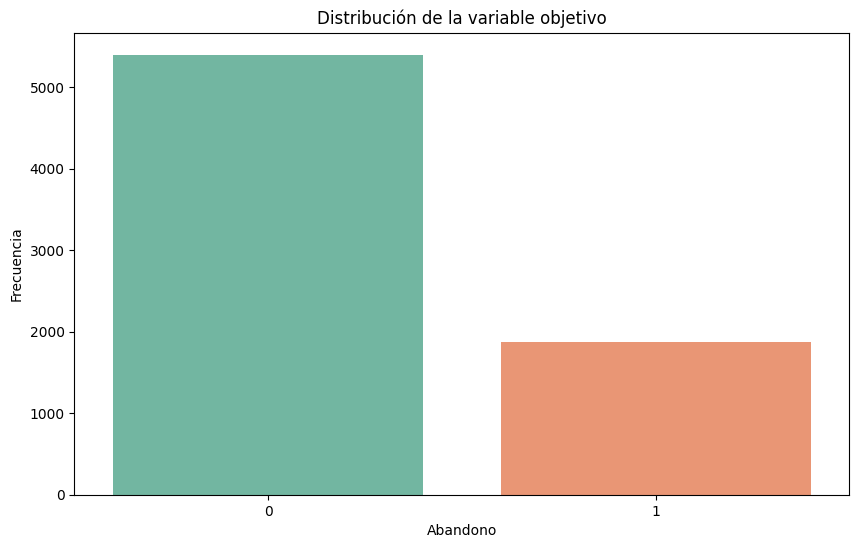

In [230]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x="Abandono", palette="Set2")
plt.title("Distribución de la variable objetivo")
plt.xlabel("Abandono")
plt.ylabel("Frecuencia")

##Correlacion y Seleccion de Variables Importantes

In [231]:
corr_abandono = df.corr()["Abandono"].sort_values(ascending=False)
corr_abandono

,Abandono
Abandono,1.000000
Servicio_Internet_Fiber optic,0.300949
Metodo_Pago_Electronic check,0.294626
Cargo_Diario,0.189866
Cargo_Mensual,0.189866
Factura_Electronica,0.186666
Adulto_Mayor,0.146733
Streaming_TV,0.062430
Streaming_Peliculas,0.060586
Lineas_Multiples,0.039343


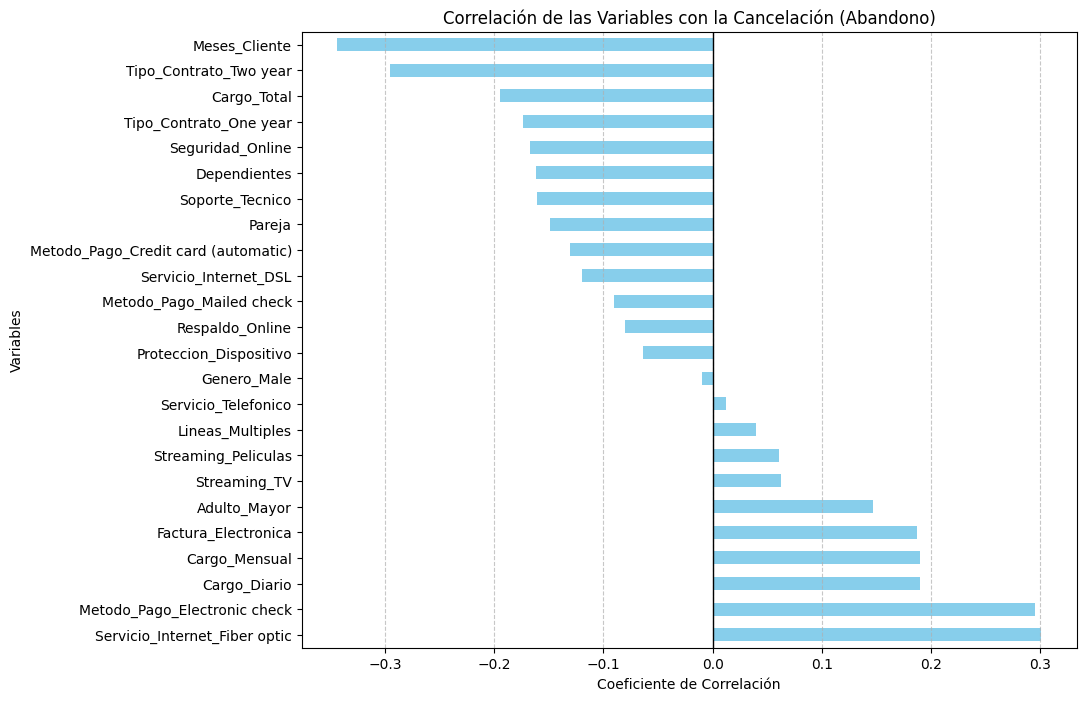

In [232]:
plt.figure(figsize=(10, 8))
corr_abandono.drop('Abandono').plot(kind='barh', color='skyblue')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Correlación de las Variables con la Cancelación (Abandono)')
plt.xlabel('Coeficiente de Correlación')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

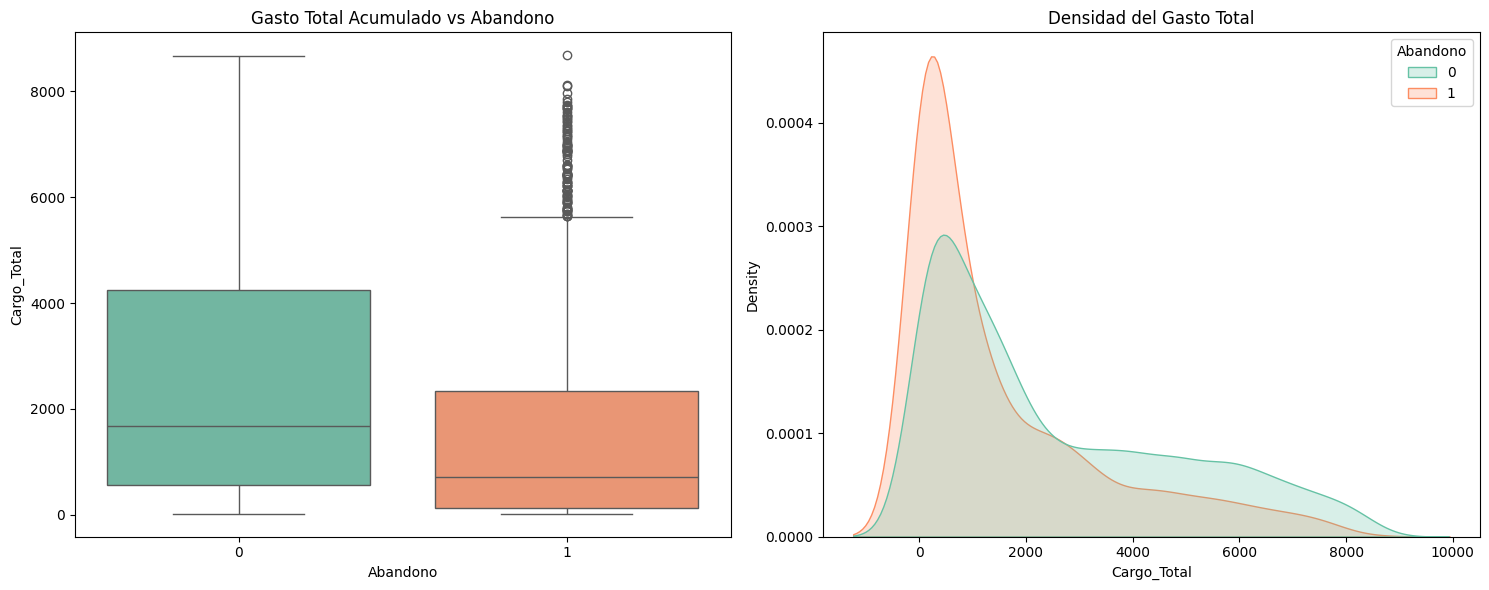

In [233]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x="Abandono", y="Cargo_Total", palette="Set2", ax=ax[0])
ax[0].set_title("Gasto Total Acumulado vs Abandono")


sns.kdeplot(data=df, x="Cargo_Total", hue="Abandono", fill=True, common_norm=False, palette="Set2", ax=ax[1])
ax[1].set_title("Densidad del Gasto Total")

plt.tight_layout()
plt.show()

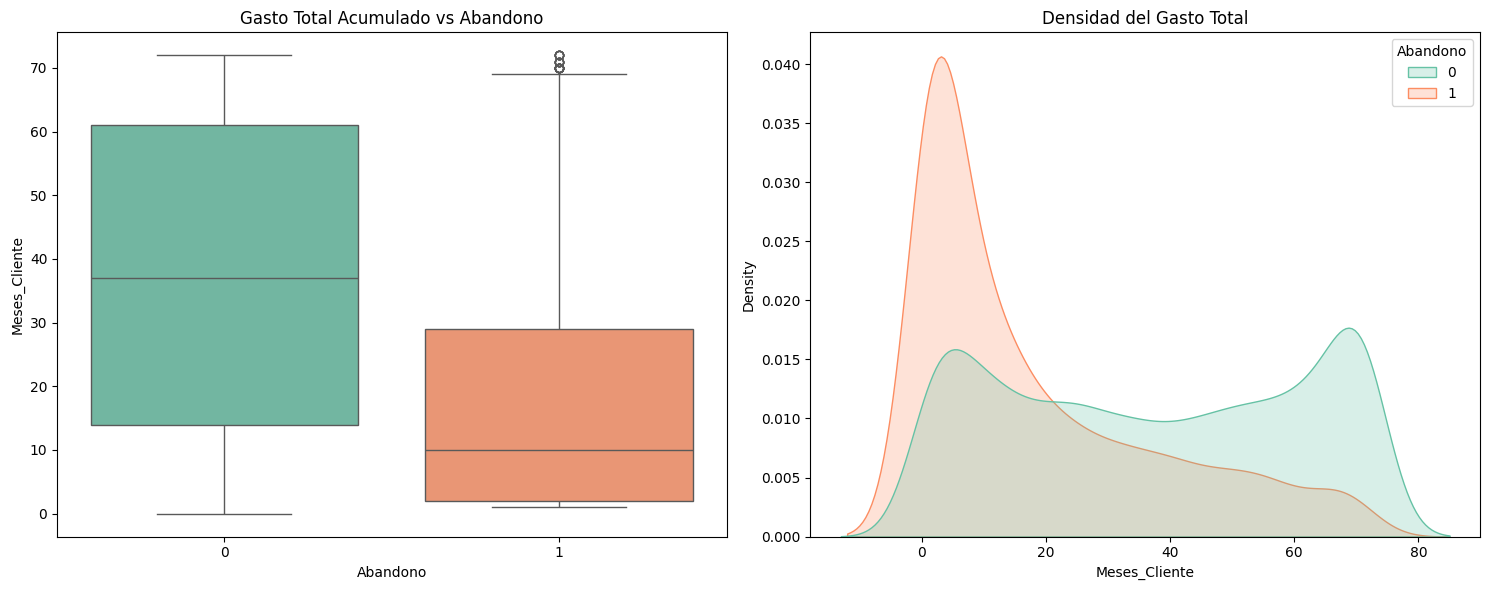

In [234]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x="Abandono", y="Meses_Cliente", palette="Set2", ax=ax[0])
ax[0].set_title("Gasto Total Acumulado vs Abandono")


sns.kdeplot(data=df, x="Meses_Cliente", hue="Abandono", fill=True, common_norm=False, palette="Set2", ax=ax[1])
ax[1].set_title("Densidad del Gasto Total")

plt.tight_layout()
plt.show()

##Modelos Predictivos

####Separando datos de entrenamiento y prueba

In [235]:

x = df.drop(columns="Abandono")
y = df["Abandono"]
X_train, X_test, y_train , y_test = train_test_split(x,y,random_state=46, test_size=0.30 , stratify=y )

In [236]:
mean_cargo_total = X_train["Cargo_Total"].mean()
X_train["Cargo_Total"] = X_train["Cargo_Total"].fillna(mean_cargo_total)
X_test["Cargo_Total"] = X_test["Cargo_Total"].fillna(mean_cargo_total)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

###Dumy model - Baseline

In [237]:
from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train_smote, y_train_smote)


DummyClassifier(strategy='most_frequent')

In [238]:
dummy_model.score(X_train_smote, y_train_smote)


0.5

In [239]:
dummy_model.predict(X_test)
dummy_model.score(X_test, y_test)



0.7427785419532325

In [240]:
evaluacion_modelo(y_test, dummy_model.predict(X_test))

{'Exactitud (Accuracy)': 0.7427785419532325,
 'Precisión': 0.0,
 'Recall (Exhaustividad)': 0.0,
 'F1-Score': 0.0}

###Arbol de desicion

In [241]:
from sklearn.tree import DecisionTreeClassifier
arbol_decision = DecisionTreeClassifier(max_depth=5)
arbol_decision.fit(X_train_smote, y_train_smote )


DecisionTreeClassifier(max_depth=5)

In [242]:
arbol_decision.score(X_train_smote, y_train_smote)

0.808628904182107

In [243]:
arbol_decision.predict(X_test)


array([0, 0, 1, ..., 0, 0, 0])

In [244]:
arbol_decision.score(X_test, y_test)

0.7487391104997707

###Random Forest

In [245]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier( max_depth=3 )
random_forest.fit(X_train_smote, y_train_smote)


RandomForestClassifier(max_depth=3)

In [246]:
random_forest.score(X_train_smote, y_train_smote)

0.8055849655902594

In [247]:
random_forest.predict(X_test)

array([0, 0, 1, ..., 0, 0, 0])

In [248]:
random_forest.score(X_test, y_test)

0.7675378266850069

###Knn

#####Normalizacion de los datos

Se aplicó la técnica de Min-Max Scaling para transformar todas las características al rango [0, 1]. De esta manera, el valor mínimo de cada columna (como el cargo mensual más bajo) se convierte en 0 y el máximo en 1. Esto garantiza que cada variable de Telecom X tenga exactamente el mismo peso potencial en la decisión final del algoritmo.

Si no normalizamos, las variables con rangos numéricos más grandes dominan el cálculo. Por ejemplo, una diferencia de $1,000 en el Cargo_Total eclipsaría por completo una diferencia de 1 en la variable Adulto_Mayor o Meses_Cliente. El modelo creería erróneamente que el gasto es miles de veces más importante que la antigüedad, simplemente porque el número es más grande.

In [249]:
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train_smote)
X_test_normalizado = normalizacion.transform(X_test)


#####Modelo knn

In [250]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_normalizado, y_train_smote)

KNeighborsClassifier()

In [251]:
knn_model.score(X_train_normalizado, y_train_smote)

0.8661990471148756

In [252]:
knn_model.predict(X_test_normalizado)


array([0, 1, 0, ..., 0, 0, 0])

In [253]:
knn_model.score(X_test_normalizado, y_test)

0.745988078862907

###Evaluacion de los modelos

In [254]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score , confusion_matrix
def evaluacion_modelo(y_test, y_pred):
    metricas = {
        "Exactitud (Accuracy)": accuracy_score(y_test, y_pred),
        "Precisión": precision_score(y_test, y_pred),
        "Recall (Exhaustividad)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }
    return metricas
evaluacion_arbol = evaluacion_modelo(y_test, arbol_decision.predict(X_test))
print(f" Modelo arbol  {evaluacion_arbol}")
evaluacion_random_forest = evaluacion_modelo(y_test, random_forest.predict(X_test))
print(f" Modelo random forest  {evaluacion_random_forest}")
evaluacion_knn = evaluacion_modelo(y_test, knn_model.predict(X_test_normalizado))
print(f" Modelo knn  {evaluacion_knn}")



 Modelo arbol  {'Exactitud (Accuracy)': 0.7487391104997707, 'Precisión': 0.5084745762711864, 'Recall (Exhaustividad)': 0.6951871657754011, 'F1-Score': 0.5873493975903614}
 Modelo random forest  {'Exactitud (Accuracy)': 0.7675378266850069, 'Precisión': 0.5324519230769231, 'Recall (Exhaustividad)': 0.7896613190730838, 'F1-Score': 0.6360373295046662}
 Modelo knn  {'Exactitud (Accuracy)': 0.745988078862907, 'Precisión': 0.5047489823609227, 'Recall (Exhaustividad)': 0.6631016042780749, 'F1-Score': 0.5731895223420647}


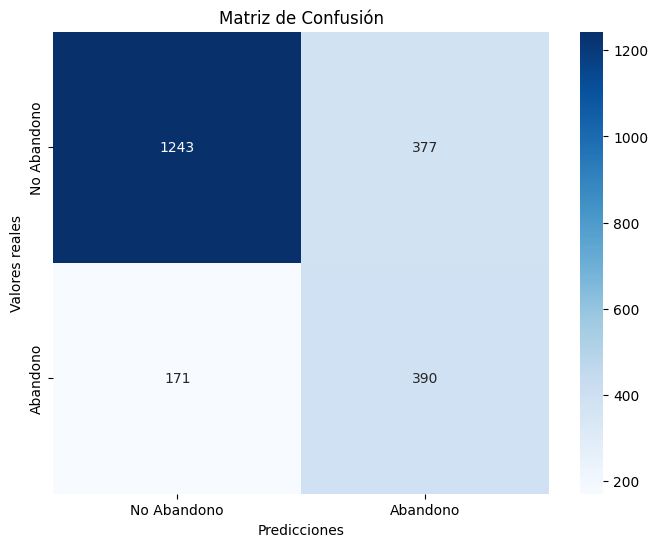

In [255]:
def matriz_confusion(y_test, y_pred):
    matriz = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(matriz, annot=True
                , fmt='g'
                , cmap='Blues'
                , xticklabels=['No Abandono', 'Abandono']
                , yticklabels=['No Abandono', 'Abandono'])
    ax.set_xlabel('Predicciones')
    ax.set_ylabel('Valores reales')
    ax.set_title('Matriz de Confusión')
    plt.show()
matriz_confusion(y_test, arbol_decision.predict(X_test))


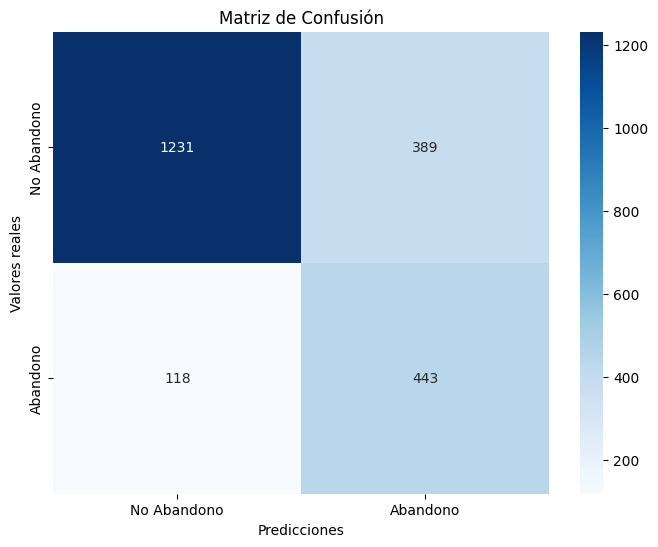

In [256]:
matriz_confusion(y_test, random_forest.predict(X_test))

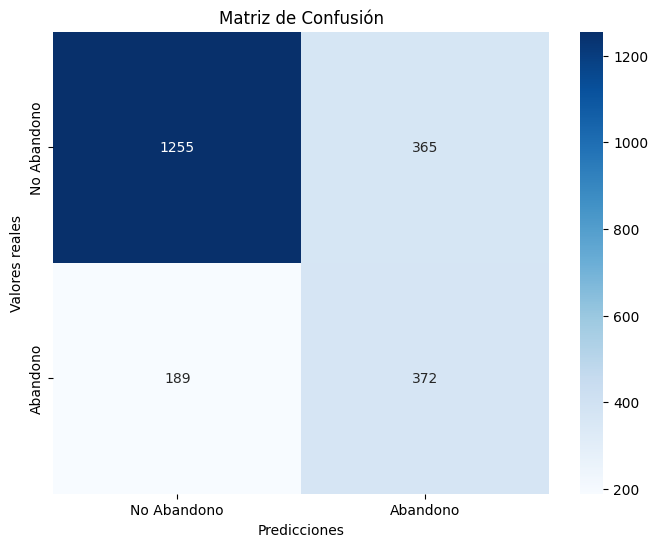

In [257]:
matriz_confusion(y_test, knn_model.predict(X_test_normalizado))

#####**Mejor desempeño**

Para el Negocio: El Random Forest es el modelo más equilibrado y robusto, con la mayor exactitud y F1-Score. Es el modelo que mejor separa las clases de forma general. Ademas tiene el Recall más alto (66.3%). Esto significa que es el mejor modelo para detectar a los clientes que realmente se van a ir.

Análisis de Overfitting / Underfitting:

Árbol de Decisión (Overfitting): Este presentaba valores de sobre ajuste en el las stats de prueba, pero cuando le coloque un max_depth se ajusto un poco mas a los resultados que dan los modelos con los datos de prueba.  

Random Forest (Equilibrado): Al ser un ensamble de muchos árboles, reduce el overfitting natural de los árboles individuales, logrando la mejor generalización y ajustando su max_depth a una cantidad limitada de ramas los resultados se vuelven mas precisos, lo que lo hace el mejor modelo segun las estadisticas.

KNN (Sensible al Ruido): Su desempeño es aceptable, pero depende críticamente de la normalización. No presenta un desajuste evidente, pero su capacidad de predicción es limitada comparada con el ensamble de bosques.

###Exportacion del modelo champion

In [258]:
with open('modelo_champion.pkl', 'wb') as archivo:
    pickle.dump(random_forest, archivo)

##Informe Final y Recomendaciones

#####Variables mas importantes para el modelo Random Forest

* Antigüedad de los clientes: Es el predictor más fuerte. A menor cantidad de meses, la probabilidad de abandono aumenta drásticamente (correlación negativa de -0.34).

* Tipos de Contrato: Los contratos Mes a Mes son la principal fuente de fuga. Los contratos de 1 o 2 años actúan como el factor de retención más potente.

* Tecnología: Sorprendentemente, los usuarios de Fibra Óptica tienen una correlación positiva con el abandono, lo que sugiere insatisfacción con el precio o problemas técnicos en este servicio específico.

* Los métodos de Pago: Los clientes que pagan con cheque electrónico tienen una tendencia mucho mayor a cancelar frente a los que usan pagos automáticos.

* Cargo total: Las personas con un cargo total mas bajo son las mas propensas a darse de baja.

####Conclucion



*****
#####**Recomendaciones Estratégicas para fidelizar clientes**

Para reducir la tasa de abandono (que actualmente se sitúa en un 25.72%), se sugiere a la gerencia implementar las siguientes acciones:

Fomentar la migración a contratos a largo plazo: Diseñar campañas agresivas de fidelización (como meses con descuento o mejoras en la velocidad) orientadas a convencer a los clientes "Mes a Mes" para que se comprometan a contratos de 1 o 2 años.

Programa de contención para clientes nuevos: Dado que el abandono ocurre principalmente al inicio de la relación comercial, se debe crear un "plan de onboarding". Esto incluye soporte proactivo y seguimiento constante durante los primeros 6 meses para asegurar una excelente experiencia de servicio.

Auditoría profunda al servicio de Fibra Óptica: Es crítico investigar las causas detrás de la insatisfacción en este segmento. Se recomienda enviar encuestas de calidad focalizadas a estos usuarios y evaluar si existen problemas de infraestructura, intermitencias o si el precio está por encima del promedio del mercado local.

Incentivar los pagos automáticos: Crear pequeñas recompensas (como la bonificación de cargos administrativos o un pequeño porcentaje de descuento en la factura) para motivar a los usuarios que pagan por cheque electrónico a que domicilien sus pagos a tarjetas de crédito. Esto reducirá la fricción operativa y aumentará la retención pasiva.